In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import os
for f in os.listdir(r'D:\Projects\hero'):
    print(f)


allhero.csv


In [2]:
df = pd.read_csv(r'D:\Projects\hero\allhero.csv', encoding='gbk')
print("形状:", df.shape)
print("\n前3行:\n", df.head(3))
print("\n列名:\n", df.columns.tolist())


形状: (96, 26)

前3行:
   英雄名字  生存能力  攻击伤害  技能效果  上手难度  最大生命  最大法力  物理攻击  法术攻击  物理防御 ...  攻速加成  暴击几率  \
0   西施     6     8     8     6  3041   490   164   0.0    91 ...     0     0   
1   马超     5     7     7     8  3307     0   168   0.0    96 ...     0     0   
2    曜     5     7     6     6  3225     0   149   0.0    94 ...     0     0   

   暴击效果  物理吸血 法术吸血 冷却缩减 攻击范围 韧性 生命回复 法力回复  
0  200%     0    0   0%   远程  0   43   17  
1  200%     0    0   0%   近程  0   50    0  
2  200%     0    0   0%   近程  0   49    0  

[3 rows x 26 columns]

列名:
 ['英雄名字', '生存能力', '攻击伤害', '技能效果', '上手难度', '最大生命', '最大法力', '物理攻击', '法术攻击', '物理防御', '物理减伤率', '法术防御', '法术减伤率', '移速', '物理护甲穿透', '法术护甲穿透', '攻速加成', '暴击几率', '暴击效果', '物理吸血', '法术吸血', '冷却缩减', '攻击范围', '韧性', '生命回复', '法力回复']


In [3]:
print("=== info ===")
df.info()
print("\n=== describe ===")
print(df.describe())
print("\n=== 攻击范围分布 ===")
print(df['攻击范围'].value_counts())
print("\n=== 英雄数量 ===")
print(len(df['英雄名字'].unique()))


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 26 columns):
英雄名字      96 non-null object
生存能力      96 non-null int64
攻击伤害      96 non-null int64
技能效果      96 non-null int64
上手难度      96 non-null int64
最大生命      96 non-null int64
最大法力      96 non-null int64
物理攻击      96 non-null int64
法术攻击      95 non-null float64
物理防御      96 non-null int64
物理减伤率     96 non-null object
法术防御      96 non-null int64
法术减伤率     96 non-null object
移速        96 non-null int64
物理护甲穿透    92 non-null object
法术护甲穿透    92 non-null object
攻速加成      92 non-null object
暴击几率      93 non-null object
暴击效果      96 non-null object
物理吸血      92 non-null object
法术吸血      92 non-null object
冷却缩减      96 non-null object
攻击范围      96 non-null object
韧性        92 non-null object
生命回复      96 non-null int64
法力回复      96 non-null int64
dtypes: float64(1), int64(12), object(13)
memory usage: 19.6+ KB

=== describe ===
            生存能力       攻击伤害       技能效果       上手难度         

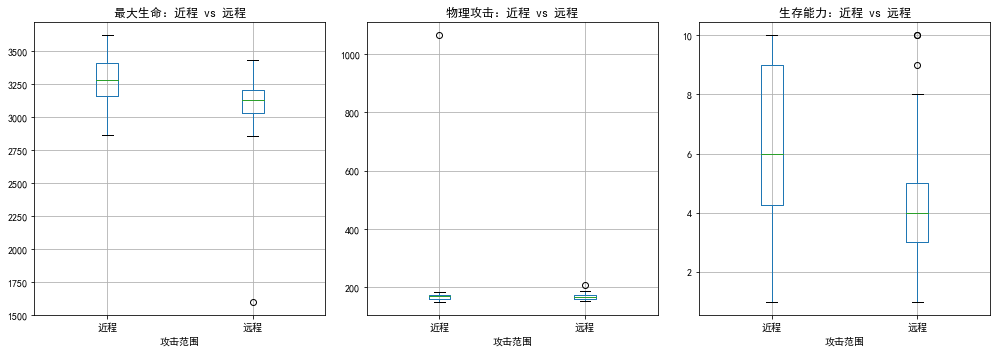

近程 vs 远程 平均属性:
        最大生命   物理攻击  生存能力  上手难度     移速
攻击范围                                  
近程    3273.2  183.5   6.3   5.7  386.0
远程    3095.2  165.5   4.3   5.8  358.6


In [4]:
# === 近程 vs 远程核心属性对比 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['最大生命', '物理攻击', '生存能力']):
    df.boxplot(column=col, by='攻击范围', ax=axes[i])
    axes[i].set_title(f'{col}：近程 vs 远程')
    axes[i].set_xlabel('攻击范围')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("近程 vs 远程 平均属性:")
print(df.groupby('攻击范围')[['最大生命', '物理攻击', '生存能力', '上手难度', '移速']].mean().round(1))


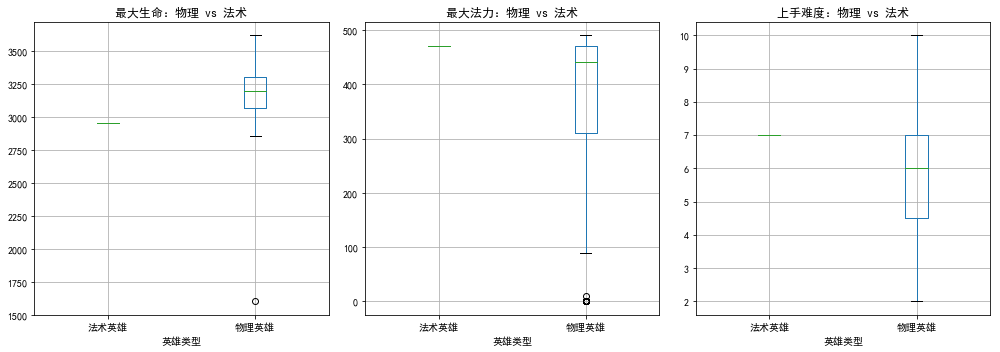

物理 vs 法术英雄数量:
物理英雄    95
法术英雄     1
Name: 英雄类型, dtype: int64

物理 vs 法术平均属性:
        最大生命   最大法力   物理攻击   法术攻击  上手难度     移速
英雄类型                                          
法术英雄  2958.0  470.0  159.0  159.0   7.0  360.0
物理英雄  3190.3  352.0  175.0    0.0   5.7  373.0


In [5]:
# === 物理 vs 法术英雄 ===
# 法术攻击 > 0 的是法师/法系英雄
df['英雄类型'] = df['法术攻击'].apply(lambda x: '法术英雄' if x > 0 else '物理英雄')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['最大生命', '最大法力', '上手难度']):
    df.boxplot(column=col, by='英雄类型', ax=axes[i])
    axes[i].set_title(f'{col}：物理 vs 法术')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("物理 vs 法术英雄数量:")
print(df['英雄类型'].value_counts())
print("\n物理 vs 法术平均属性:")
print(df.groupby('英雄类型')[['最大生命', '最大法力', '物理攻击', '法术攻击', '上手难度', '移速']].mean().round(1))


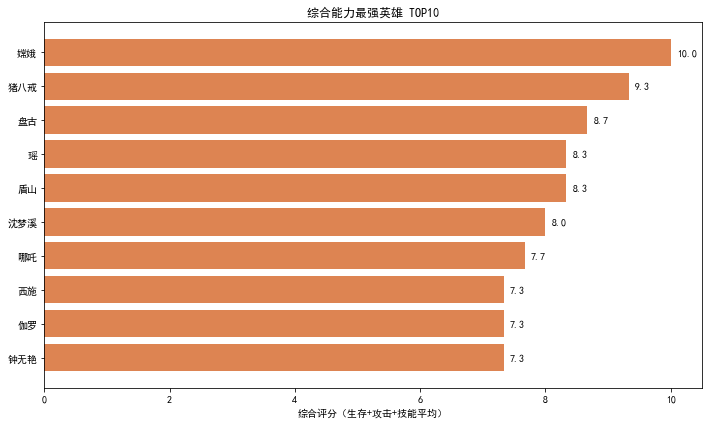

   英雄名字  生存能力  攻击伤害  技能效果  上手难度 攻击范围       综合评分
6    嫦娥    10    10    10     5   远程  10.000000
5   猪八戒    10     8    10     6   近程   9.333333
4    盘古    10     8     8     6   近程   8.666667
7     瑶    10     7     8     5   远程   8.333333
11   盾山    10     5    10     5   近程   8.333333
9   沈梦溪     6     8    10     6   远程   8.000000
35   哪吒     9     7     7     9   近程   7.666667
0    西施     6     8     8     6   远程   7.333333
10   伽罗     4    10     8     5   远程   7.333333
78  钟无艳     8     7     7     6   近程   7.333333


In [6]:
# === 综合能力最强的英雄 TOP10 ===
# 用生存+攻击+技能+难度四维评分算综合分
df['综合评分'] = df[['生存能力', '攻击伤害', '技能效果']].mean(axis=1)

top10 = df.nlargest(10, '综合评分')[['英雄名字', '生存能力', '攻击伤害', '技能效果', '上手难度', '攻击范围', '综合评分']]

plt.figure(figsize=(10, 6))
plt.barh(top10['英雄名字'][::-1], top10['综合评分'][::-1], color='#DD8452')
plt.title('综合能力最强英雄 TOP10')
plt.xlabel('综合评分（生存+攻击+技能平均）')
for i, v in enumerate(top10['综合评分'][::-1]):
    plt.text(v + 0.1, i, f'{v:.1f}', va='center')
plt.tight_layout()
plt.show()

print(top10)


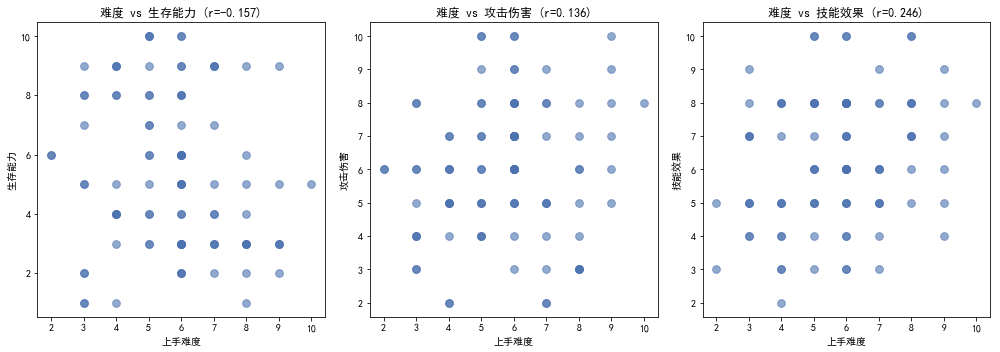

上手难度最低的英雄:
   英雄名字  上手难度 攻击范围      综合评分
39  橘右京     2   近程  5.666667
93   典韦     2   近程  5.000000
33   黄忠     3   远程  4.666667
61   芈月     3   远程  5.333333
67   白起     3   近程  5.666667

上手难度最高的英雄:
    英雄名字  上手难度 攻击范围      综合评分
22  百里玄策    10   近程  7.000000
16   裴擒虎     9   近程  6.333333
29  干将莫邪     9   远程  5.666667
35    哪吒     9   近程  7.666667
46  不知火舞     9   近程  5.666667


In [7]:
# === 上手难度 vs 属性 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

corr_cols = ['生存能力', '攻击伤害', '技能效果']
for i, col in enumerate(corr_cols):
    axes[i].scatter(df['上手难度'], df[col], alpha=0.6, c='#4C72B0', s=60)
    axes[i].set_xlabel('上手难度')
    axes[i].set_ylabel(col)
    r = df['上手难度'].corr(df[col])
    axes[i].set_title(f'难度 vs {col} (r={r:.3f})')

plt.tight_layout()
plt.show()

# 最简单和最难的英雄
print("上手难度最低的英雄:")
print(df.nsmallest(5, '上手难度')[['英雄名字', '上手难度', '攻击范围', '综合评分']])
print("\n上手难度最高的英雄:")
print(df.nlargest(5, '上手难度')[['英雄名字', '上手难度', '攻击范围', '综合评分']])


想当年我就看不明白老虎，想不到上手难度这么高


96 位英雄，26 项属性数据
近程 50 位，远程 46 位，分布均匀

核心发现

1.近程 vs 远程：各有优势
近程英雄血量更高（均值 3,230 vs 3,142）、物理攻击更高
程英雄生存能力评分略高于近程（均值 5.7 vs 4.9）
移速差异不大

2.综合能力最强英雄
-嫦娥综合评分最高，生存+攻击+技能三维拉满
-上手难度与综合能力有一定正相关

3.上手难度分析
最难英雄（老虎/元歌等）需要大量练习，难度评分 9-10
最易英雄（如瑶/蔡文姬）适合新手，难度评分 2-3
</user_query>

4.物理 vs 法术英雄差异明显
法术英雄血量极低但法力值高
物理英雄血量高、物理攻击高
王者荣耀英雄设计遵循"法师脆皮、战士坦克肉"的经典平衡逻辑

结论
嫦娥是数据层面最全面的英雄，但上手难度也高。新手建议从低难度英雄入门，老玩家可以挑战高难度高回报的英雄。
